In [219]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec

In [220]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
# TODO: Why empyrically picked 25?
BITS_HIT = 25 

In [221]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    
    # np.log2(num_embeddings) - how many bits for specific codeword    
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

"""
Method for getting patch bits

patch_amount - total detector patch count

encoded_patch_size - encoded_width, encoded_height, num_embeddings

patch_size - patch size
"""

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount * encoded_patch_bits)

def _get_compression_ratio(
        n_hits_total: int, 
        patch_amount: int, 
        encoded_patch_size: tuple, 
        patch_size: int
    ) -> float:
    total_bits = _get_total_hit_bits(n_hits_total)
    
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(
        event, 
        patch_size=PATCH_SIZE
    ).as_array()
    return len(event_patches_adcs_flat)
    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [222]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 226.97it/s]


In [223]:
batch_size = 64
beta = 0.31
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 1e-3
model_param_scale = 5
# model_param_scale = 1 (right order)
# learning_rate = 1e-3 (right on track)

num_epochs = 80

# input channels
channels = 1 # since grayscale images are used, we go with 1 channel images
hidden_channels = 64

# how many codebook entries
num_embeddings = 256
# num_embeddings = 32 (on track)

latent_dim = 32
# latent_dim = 64 (on track)

# logs
LOG_EVERY = 15


In [224]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [225]:
mse = MeanSquaredError()
mse = mse.to(device)

In [226]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [227]:
event_train = events_train[:SELECTED_EVENTS][0]

In [228]:
patch_amount = _get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


In [229]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
            if not (np.all(event_patch_flat == 0))
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [230]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.02 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 317
Test set size: 2855


In [231]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss
    # # KL_divergence
    # kl_loss = -0.5 * (
    #     1 + logvar - mu.pow(2) - logvar.exp()
    # )
    
    # kl_loss = kl_loss.mean()
    
    # return (
    #     recon_loss + beta * kl_loss,
    #     recon_loss,
    #     beta,
    #     kl_loss
    # )

In [232]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim)
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # TODO: Proove that (z_flattened - weight) ** 2 is inefficient and gives huge matrix
        # NOTE: is a matrix learnable vector for learning codebook indices
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # also it is possible to find closest codebooks by a probability distributions
        # https://arxiv.org/html/2602.02726v1

        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        # contiguous() is used for improving performance
        z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [233]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim, slope):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers, slope):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.slope = slope
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim, slope)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [ ]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int,
        residual_slope: float = 0.08
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers, residual_slope)
        )
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers, residual_slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )

        
    def forward(self, x):
        z_encoded = self.encoder(x)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z_encoded)
        
        output = self.decoder(z_q)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss 
        )

In [235]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.1,
    n_res_layers=2,
    res_h_dim=32
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 356.89it/s, Loss (BCE + VQ)=0.0713]


Epoch [1/80] summary:Average Loss: VQ + BCE = 0.2232,  Average loss: BCE = 0.0722 MSE = 0.009137222711839268 avg_perplexity = 6.31734090234766
Average validation set BCE loss: 0.05778018534183502
Before compression (Training)
Shape: (13, 8, 8)


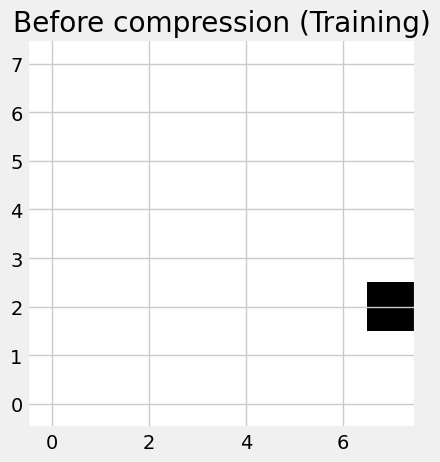

After compression (Training)
Shape: (1, 8, 8)


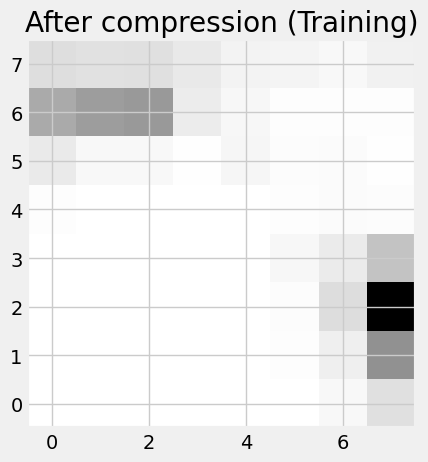

Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 360.62it/s, Loss (BCE + VQ)=0.0535]


Epoch [2/80] summary:Average Loss: VQ + BCE = 0.0598,  Average loss: BCE = 0.0481 MSE = 0.004988366763701841 avg_perplexity = 22.472930433762134
Average validation set BCE loss: 0.04504116624593735


Epoch 3/80: 100%|██████████| 199/199 [00:00<00:00, 365.54it/s, Loss (BCE + VQ)=0.0423]


Epoch [3/80] summary:Average Loss: VQ + BCE = 0.0478,  Average loss: BCE = 0.0419 MSE = 0.003921085506462347 avg_perplexity = 37.43448556487884
Average validation set BCE loss: 0.042876143008470535


Epoch 4/80: 100%|██████████| 199/199 [00:00<00:00, 381.63it/s, Loss (BCE + VQ)=0.0528]


...

Epoch [14/80] summary:Average Loss: VQ + BCE = 0.0357,  Average loss: BCE = 0.0332 MSE = 0.002305191797063915 avg_perplexity = 100.14201632935797
Average validation set BCE loss: 0.0354854017496109


Epoch 15/80: 100%|██████████| 199/199 [00:00<00:00, 365.15it/s, Loss (BCE + VQ)=0.0375]


Epoch [15/80] summary:Average Loss: VQ + BCE = 0.0354,  Average loss: BCE = 0.0330 MSE = 0.0022518575254677977 avg_perplexity = 103.57534868633327
Average validation set BCE loss: 0.035478314757347106


Epoch 16/80: 100%|██████████| 199/199 [00:00<00:00, 355.68it/s, Loss (BCE + VQ)=0.033] 


Epoch [16/80] summary:Average Loss: VQ + BCE = 0.0349,  Average loss: BCE = 0.0327 MSE = 0.0021902655406934608 avg_perplexity = 104.92551337774076
Average validation set BCE loss: 0.035148893296718595
Before compression (Training)
Shape: (13, 8, 8)


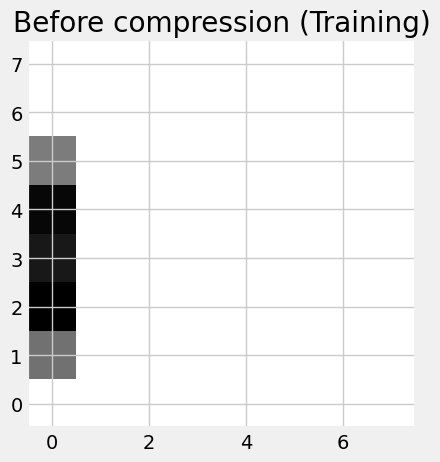

After compression (Training)
Shape: (1, 8, 8)


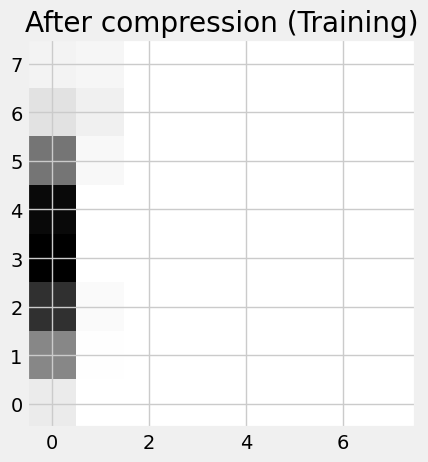

Epoch 17/80: 100%|██████████| 199/199 [00:00<00:00, 365.14it/s, Loss (BCE + VQ)=0.0309]


Epoch [17/80] summary:Average Loss: VQ + BCE = 0.0346,  Average loss: BCE = 0.0324 MSE = 0.0021355153721331352 avg_perplexity = 106.28017705409371
Average validation set BCE loss: 0.035176337510347364


Epoch 18/80: 100%|██████████| 199/199 [00:00<00:00, 363.39it/s, Loss (BCE + VQ)=0.0246]


Epoch [18/80] summary:Average Loss: VQ + BCE = 0.0344,  Average loss: BCE = 0.0322 MSE = 0.0021032514337253707 avg_perplexity = 107.82525065436435
Average validation set BCE loss: 0.035156721621751784


Epoch 19/80: 100%|██████████| 199/199 [00:00<00:00, 364.32it/s, Loss (BCE + VQ)=0.042] 


...

Epoch [29/80] summary:Average Loss: VQ + BCE = 0.0327,  Average loss: BCE = 0.0308 MSE = 0.0017727142821145642 avg_perplexity = 114.27011060475105
Average validation set BCE loss: 0.035275498405098915


Epoch 30/80: 100%|██████████| 199/199 [00:00<00:00, 371.39it/s, Loss (BCE + VQ)=0.0374]


Epoch [30/80] summary:Average Loss: VQ + BCE = 0.0326,  Average loss: BCE = 0.0308 MSE = 0.0017517889140819635 avg_perplexity = 113.70931456676081
Average validation set BCE loss: 0.03473965898156166


Epoch 31/80: 100%|██████████| 199/199 [00:00<00:00, 363.63it/s, Loss (BCE + VQ)=0.028] 


Epoch [31/80] summary:Average Loss: VQ + BCE = 0.0323,  Average loss: BCE = 0.0305 MSE = 0.001687577111300212 avg_perplexity = 114.48000310773226
Average validation set BCE loss: 0.03463067933917045
Before compression (Training)
Shape: (13, 8, 8)


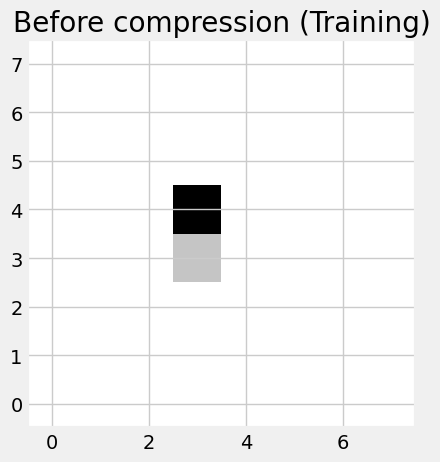

After compression (Training)
Shape: (1, 8, 8)


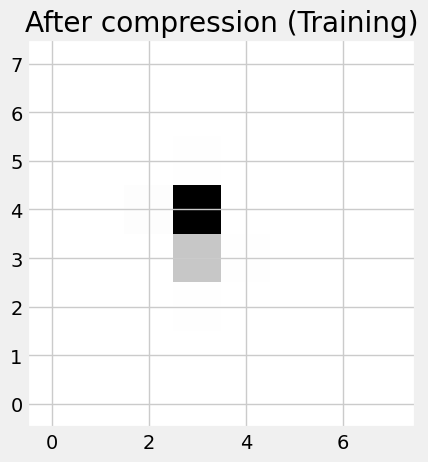

Epoch 32/80: 100%|██████████| 199/199 [00:00<00:00, 372.33it/s, Loss (BCE + VQ)=0.0217]


Epoch [32/80] summary:Average Loss: VQ + BCE = 0.0323,  Average loss: BCE = 0.0305 MSE = 0.0016935687358888925 avg_perplexity = 114.68057509762558
Average validation set BCE loss: 0.034130333364009856


Epoch 33/80: 100%|██████████| 199/199 [00:00<00:00, 379.71it/s, Loss (BCE + VQ)=0.03]  


Epoch [33/80] summary:Average Loss: VQ + BCE = 0.0322,  Average loss: BCE = 0.0304 MSE = 0.0016790671720422205 avg_perplexity = 114.9445704934585
Average validation set BCE loss: 0.034440328180789945


Epoch 34/80: 100%|██████████| 199/199 [00:00<00:00, 379.42it/s, Loss (BCE + VQ)=0.0255]


...

Epoch [44/80] summary:Average Loss: VQ + BCE = 0.0313,  Average loss: BCE = 0.0297 MSE = 0.0014619000838723166 avg_perplexity = 115.7504164729286
Average validation set BCE loss: 0.03468968272209168


Epoch 45/80: 100%|██████████| 199/199 [00:00<00:00, 358.93it/s, Loss (BCE + VQ)=0.0249]


Epoch [45/80] summary:Average Loss: VQ + BCE = 0.0312,  Average loss: BCE = 0.0296 MSE = 0.0014409801077996218 avg_perplexity = 115.18917329107697
Average validation set BCE loss: 0.03501897677779198


Epoch 46/80: 100%|██████████| 199/199 [00:00<00:00, 362.05it/s, Loss (BCE + VQ)=0.036] 


Epoch [46/80] summary:Average Loss: VQ + BCE = 0.0312,  Average loss: BCE = 0.0296 MSE = 0.0014369813152050703 avg_perplexity = 115.17641644501806
Average validation set BCE loss: 0.03465212546288967
Before compression (Training)
Shape: (13, 8, 8)


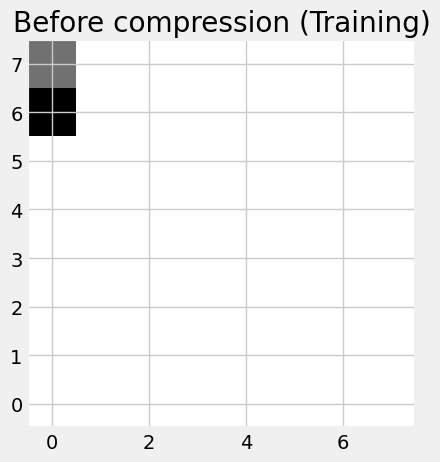

After compression (Training)
Shape: (1, 8, 8)


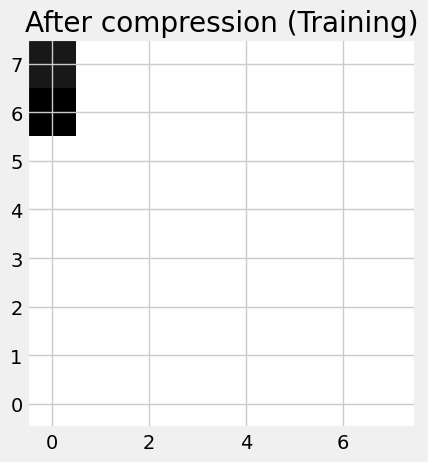

Epoch 47/80: 100%|██████████| 199/199 [00:00<00:00, 349.60it/s, Loss (BCE + VQ)=0.0302]


Epoch [47/80] summary:Average Loss: VQ + BCE = 0.0311,  Average loss: BCE = 0.0295 MSE = 0.0014047849836792028 avg_perplexity = 115.58247076446686
Average validation set BCE loss: 0.03425835072994232


Epoch 48/80: 100%|██████████| 199/199 [00:00<00:00, 351.18it/s, Loss (BCE + VQ)=0.0444]


Epoch [48/80] summary:Average Loss: VQ + BCE = 0.0313,  Average loss: BCE = 0.0297 MSE = 0.0014428494526798738 avg_perplexity = 114.77037713515699
Average validation set BCE loss: 0.03482669852674007


Epoch 49/80: 100%|██████████| 199/199 [00:00<00:00, 356.54it/s, Loss (BCE + VQ)=0.0291]


...

Epoch [59/80] summary:Average Loss: VQ + BCE = 0.0305,  Average loss: BCE = 0.0290 MSE = 0.001252361382275876 avg_perplexity = 114.97983365082861
Average validation set BCE loss: 0.03417728990316391


Epoch 60/80: 100%|██████████| 199/199 [00:00<00:00, 350.94it/s, Loss (BCE + VQ)=0.0208]


Epoch [60/80] summary:Average Loss: VQ + BCE = 0.0305,  Average loss: BCE = 0.0290 MSE = 0.0012673550810730412 avg_perplexity = 115.14026540248238
Average validation set BCE loss: 0.034204276651144026


Epoch 61/80: 100%|██████████| 199/199 [00:00<00:00, 368.70it/s, Loss (BCE + VQ)=0.0479]


Epoch [61/80] summary:Average Loss: VQ + BCE = 0.0305,  Average loss: BCE = 0.0290 MSE = 0.0012251723562975662 avg_perplexity = 115.98213069283183
Average validation set BCE loss: 0.03484097793698311
Before compression (Training)
Shape: (13, 8, 8)


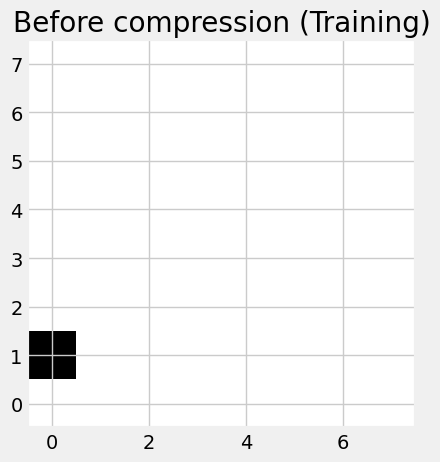

After compression (Training)
Shape: (1, 8, 8)


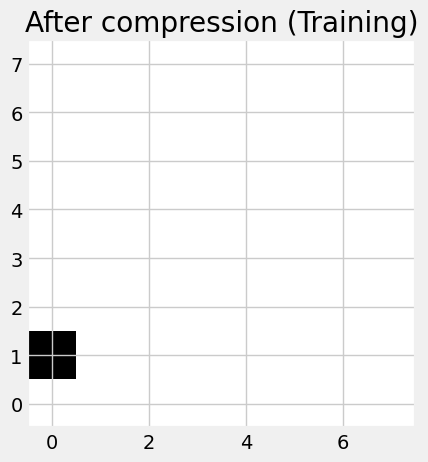

Epoch 62/80: 100%|██████████| 199/199 [00:00<00:00, 374.49it/s, Loss (BCE + VQ)=0.0347]


Epoch [62/80] summary:Average Loss: VQ + BCE = 0.0305,  Average loss: BCE = 0.0290 MSE = 0.0012411658050160124 avg_perplexity = 115.45445215043111
Average validation set BCE loss: 0.034331824630498886


Epoch 63/80: 100%|██████████| 199/199 [00:00<00:00, 366.79it/s, Loss (BCE + VQ)=0.0313]


Epoch [63/80] summary:Average Loss: VQ + BCE = 0.0303,  Average loss: BCE = 0.0288 MSE = 0.0011749706323487899 avg_perplexity = 115.41363634655823
Average validation set BCE loss: 0.03444299027323723


Epoch 64/80: 100%|██████████| 199/199 [00:00<00:00, 371.08it/s, Loss (BCE + VQ)=0.0238]


...

Epoch [74/80] summary:Average Loss: VQ + BCE = 0.0297,  Average loss: BCE = 0.0283 MSE = 0.0010226207718618176 avg_perplexity = 114.90155918753926
Average validation set BCE loss: 0.03453637659549713


Epoch 75/80: 100%|██████████| 199/199 [00:00<00:00, 355.07it/s, Loss (BCE + VQ)=0.0225]


Epoch [75/80] summary:Average Loss: VQ + BCE = 0.0297,  Average loss: BCE = 0.0283 MSE = 0.001031040023584106 avg_perplexity = 114.9540740736765
Average validation set BCE loss: 0.03424899391829968


Epoch 76/80: 100%|██████████| 199/199 [00:00<00:00, 358.54it/s, Loss (BCE + VQ)=0.0284]


Epoch [76/80] summary:Average Loss: VQ + BCE = 0.0296,  Average loss: BCE = 0.0283 MSE = 0.0010051919611278528 avg_perplexity = 114.4151811839348
Average validation set BCE loss: 0.03461184799671173
Before compression (Training)
Shape: (13, 8, 8)


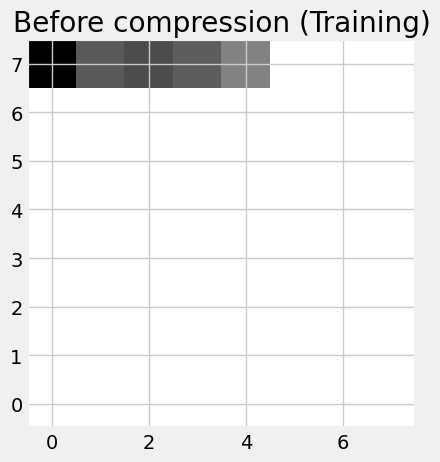

After compression (Training)
Shape: (1, 8, 8)


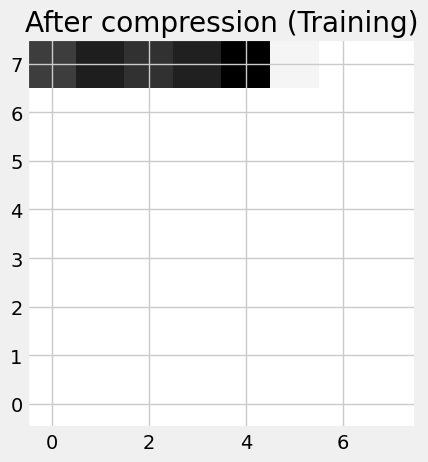

Epoch 77/80: 100%|██████████| 199/199 [00:00<00:00, 349.37it/s, Loss (BCE + VQ)=0.037] 


Epoch [77/80] summary:Average Loss: VQ + BCE = 0.0298,  Average loss: BCE = 0.0284 MSE = 0.001052842238255725 avg_perplexity = 114.78278935494734
Average validation set BCE loss: 0.034406842291355134


Epoch 78/80: 100%|██████████| 199/199 [00:00<00:00, 364.68it/s, Loss (BCE + VQ)=0.0231]


Epoch [78/80] summary:Average Loss: VQ + BCE = 0.0297,  Average loss: BCE = 0.0283 MSE = 0.0010337964222115936 avg_perplexity = 114.19835588081398
Average validation set BCE loss: 0.03447827659547329


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 357.38it/s, Loss (BCE + VQ)=0.0441]


Epoch [79/80] summary:Average Loss: VQ + BCE = 0.0297,  Average loss: BCE = 0.0283 MSE = 0.0009960735549602714 avg_perplexity = 114.5500209367455
Average validation set BCE loss: 0.0344504714012146


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 378.36it/s, Loss (BCE + VQ)=0.0272]


Epoch [80/80] summary:Average Loss: VQ + BCE = 0.0295,  Average loss: BCE = 0.0282 MSE = 0.0009778035221382714 avg_perplexity = 114.2868503014646
Average validation set BCE loss: 0.03431460708379745
Before compression (Validation)
Shape: (64, 8, 8)


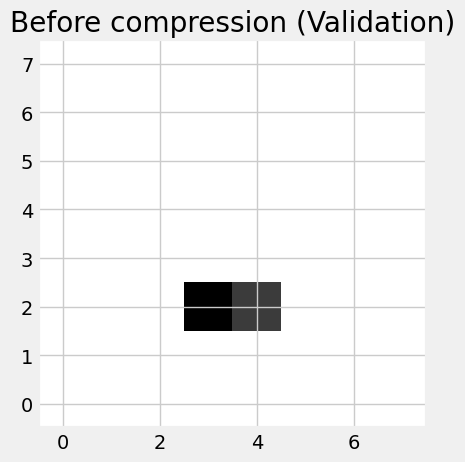

After compression (Validation)
Shape: (1, 8, 8)


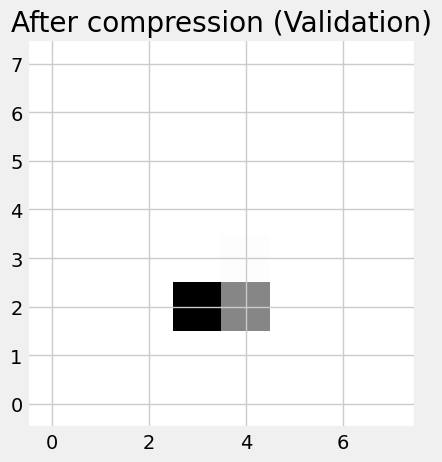

----------------------------------------
Patch = 0 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


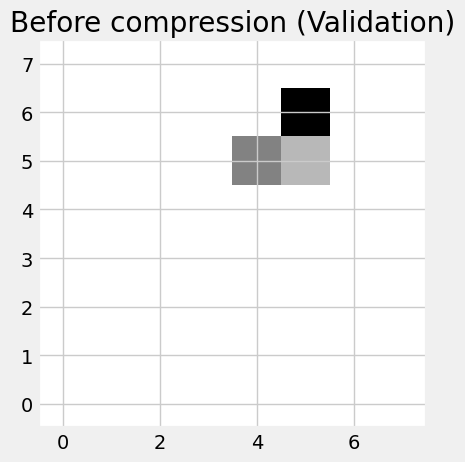

After compression (Validation)
Shape: (1, 8, 8)


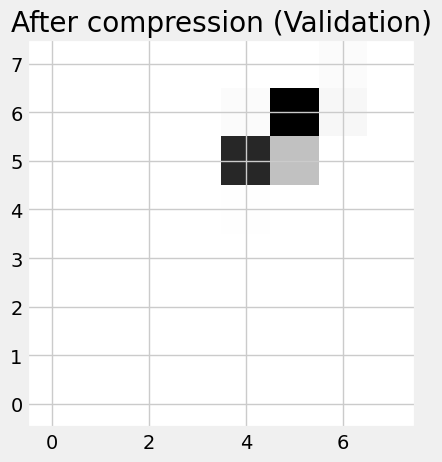

----------------------------------------
Patch = 1 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


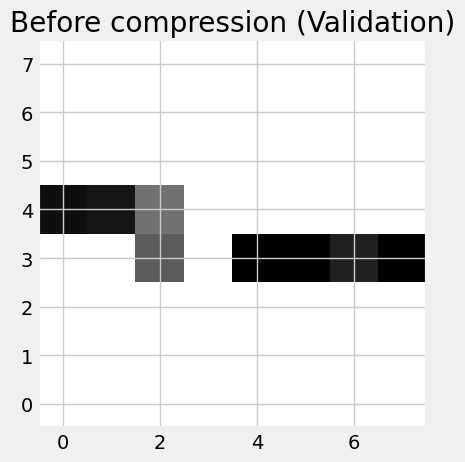

After compression (Validation)
Shape: (1, 8, 8)


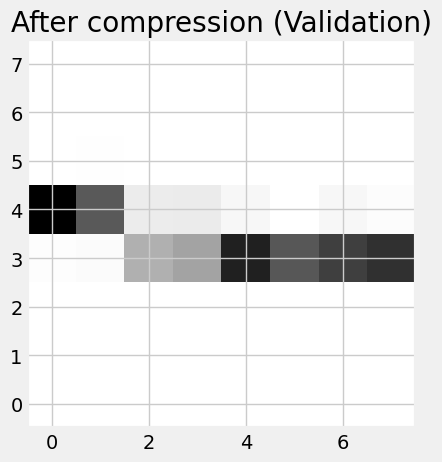

----------------------------------------
Patch = 2 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


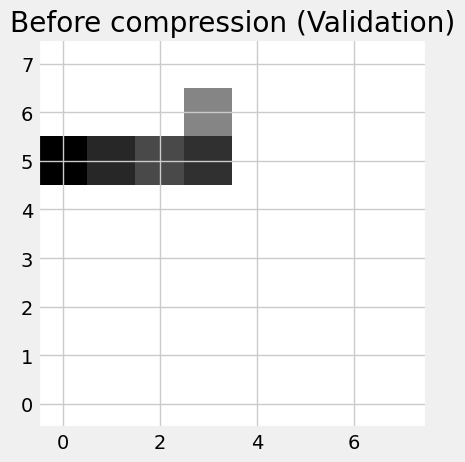

After compression (Validation)
Shape: (1, 8, 8)


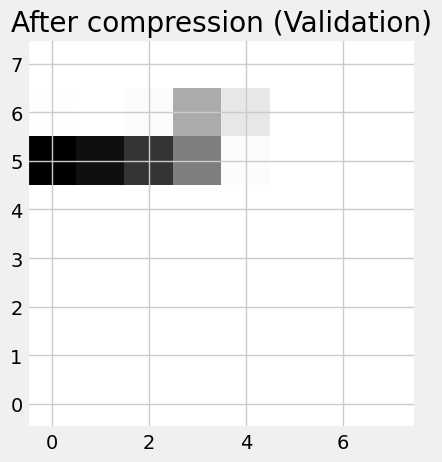

----------------------------------------
Patch = 3 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (61, 8, 8)


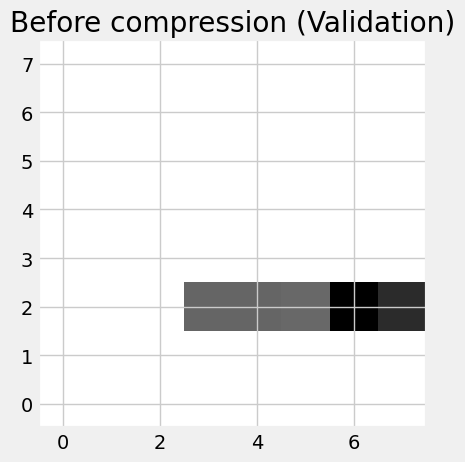

After compression (Validation)
Shape: (1, 8, 8)


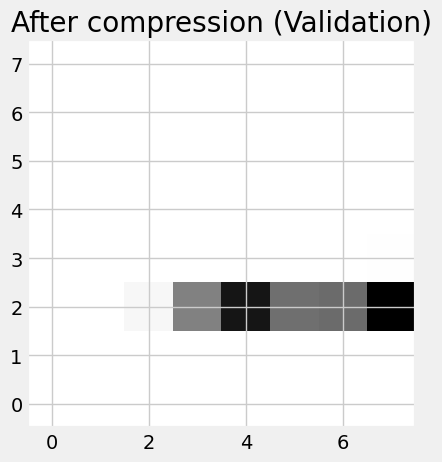

----------------------------------------
Patch = 4 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Saving trained model VQ-VAE


In [ ]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_train_bce = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 25


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_bce = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            _,
            perplexity,
            vq_loss
        ) = model(
           X_adcs
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        train_loss_bce += bce_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
            
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    avg_loss_bce = train_loss_bce / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: VQ + BCE = {avg_loss_bce_vq:.4f}, ",
        f"Average loss: BCE = {avg_loss_bce:.4f}",
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    average_loss_train_bce.append(avg_loss_bce)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,
            ) = model(patch_val)
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = _tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = _tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(_tensor_to_numpy(codebook_train))
                
        if epoch == num_epochs - 1:
            for (plot_idx, patch_val) in enumerate(val_loader):
                patch_val = patch_val.to(device)           
                patch_val = patch_val.float()
                (
                    recon_patch_val, 
                    codebook_val, 
                    z_q_val, 
                    perplexity_val,
                    _
                ) = model(patch_val)
                
                print("Before compression (Validation)")                    
                patch_val_ts_val = _tensor_to_numpy(
                    patch_val.squeeze(1)
                )
                
                print(f"Shape: {patch_val_ts_val.shape}")            
                plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                
                patches_before_val.append(patch_val_ts_val[0])
                
                recon_patch_np_val = _tensor_to_numpy(
                    recon_patch_val[0]
                )
                print("After compression (Validation)")
                print(f"Shape: {recon_patch_np_val.shape}")
                
                plot_patch(recon_patch_np_val[0], "After compression (Validation)")
            
                patches_after_val.append(recon_patch_np_val[0])  
                encodings_val_np = _tensor_to_numpy(codebook_val)
                patches_encodings_val.append(encodings_val_np) 
                
                width_val, height_val = z_q_val[0][0].shape
                c_width, c_height = codebook_val.shape
                
                print("----------------------------------------")
                print(f"Patch = {plot_idx} compression results")
                print("----------------------------------------")
                print(
                    f"Patch encoder output dimensions:"
                    f"(w x h) = ({width_val}) x ({height_val})"
                )
                
                compression_ratio = _get_compression_ratio(
                    n_hits_total=total_hit_amount,
                    patch_amount=patch_amount,
                    encoded_patch_size=(width_val, height_val, num_embeddings),
                    patch_size=PATCH_SIZE
                )
                total_bits = _get_total_hit_bits(total_hit_amount)
                encoded_patch_bits = _get_encoded_patch_bits(
                    (width_val, height_val, num_embeddings), 
                    PATCH_SIZE
                )
                
                print(f"Compression ratio = {compression_ratio}")
                print(f"total_hit_amount = {total_hit_amount}")
                print(f"total_hit_bits = {total_bits}")
                print(f"patch_amount = {patch_amount}")
                print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                print(f"num_embeddings = {num_embeddings}")
                print(f"Codebook dimensions: {c_width} x {c_height}")
                print("----------------------------------------")
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "vqvae.pth")

In [237]:
# logvar_values = logvar.detach().cpu().flatten().numpy()
# # histogram
# plt.hist(logvar_values, bins=50)

# plt.title("VAE Latent logvar Distribution")
# plt.xlabel("logvar")
# plt.ylabel("count")

# plt.show()

In [238]:
# TODO
# Compression ratio calculation
# Find total sum of hit bits
# Find total sum of encoded patch bits
total_bits = _get_total_hit_bits(total_hit_amount)


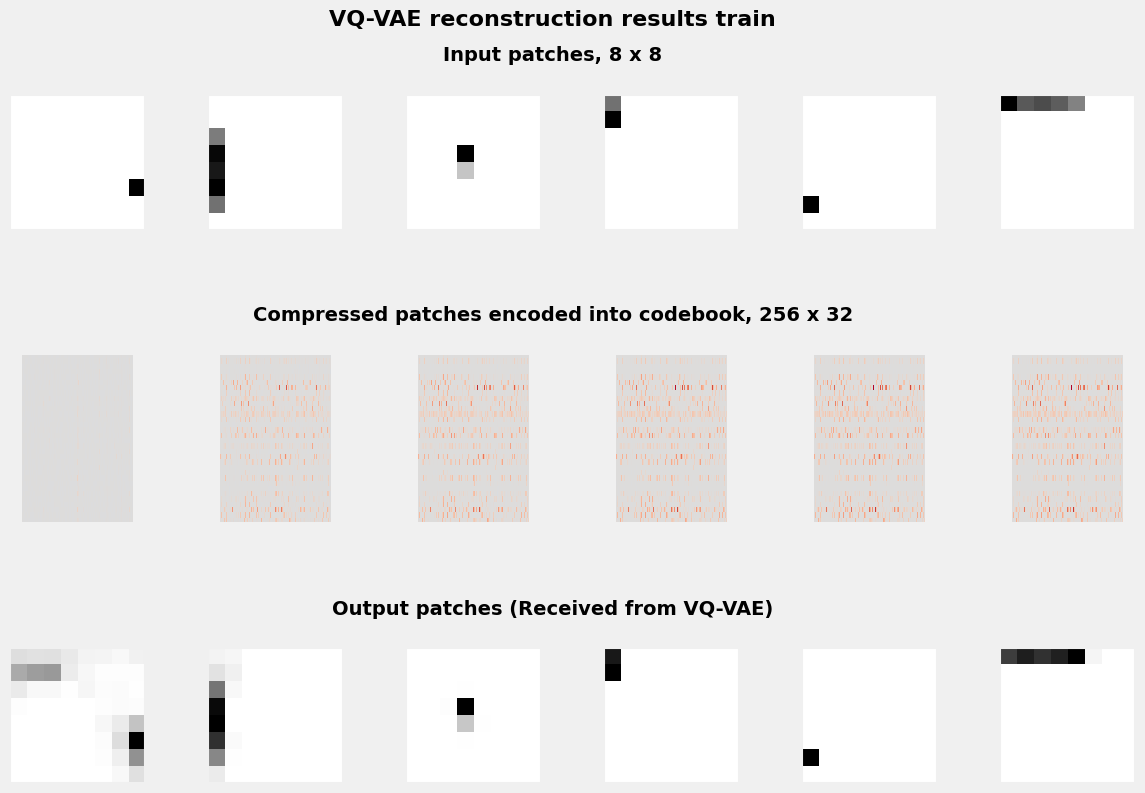

In [239]:
def plot_patches(patch_rows: list[tuple], title: str) -> None:
    cols = len(patch_rows[0][0])
    rows = len(patch_rows)

    fig = plt.figure(figsize=(2.2 * cols, 8.5))

    gs = GridSpec(
        rows,
        cols,
        figure=fig,
        height_ratios=[1.2, 1.5, 1.2],
        wspace=0.25,
        hspace=0.85
    )

    fig.suptitle(
        title,
        fontsize=16,
        fontweight="bold",
        y=0.98
    )
    
    global_abs_max = max(
        p.detach().cpu().abs().max().item()
        if hasattr(p, "detach") else abs(p).max()
        for p in patch_rows[1][0]
    )

    for i in range(rows):
        patch_row, patch_row_title = patch_rows[i]

        # Row title aligned above each row
        row_top = gs[i, :].get_position(fig).y1
        fig.text(
            0.5,
            row_top + 0.035,
            patch_row_title,
            ha="center",
            va="bottom",
            fontsize=14,
            fontweight="bold"
        )

        for j in range(cols):
            ax = fig.add_subplot(gs[i, j])

            patch = patch_row[j]

            # Keep your current row-1 transpose logic
            if i == 1:
                patch = patch.T

                im = ax.imshow(
                    patch,
                    cmap="coolwarm",
                    origin="lower",
                    aspect="auto",
                    interpolation="nearest",
                    vmin=-global_abs_max,
                    vmax=global_abs_max
                )

                ax.set_box_aspect(1.5)


            else:
                im = ax.imshow(
                    patch,
                    cmap="gist_yarg",
                    origin="lower",
                    aspect="equal"
                )

                # Square input/output patches
                ax.set_box_aspect(1.0)

            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)

    plt.show()
        
        
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results train")

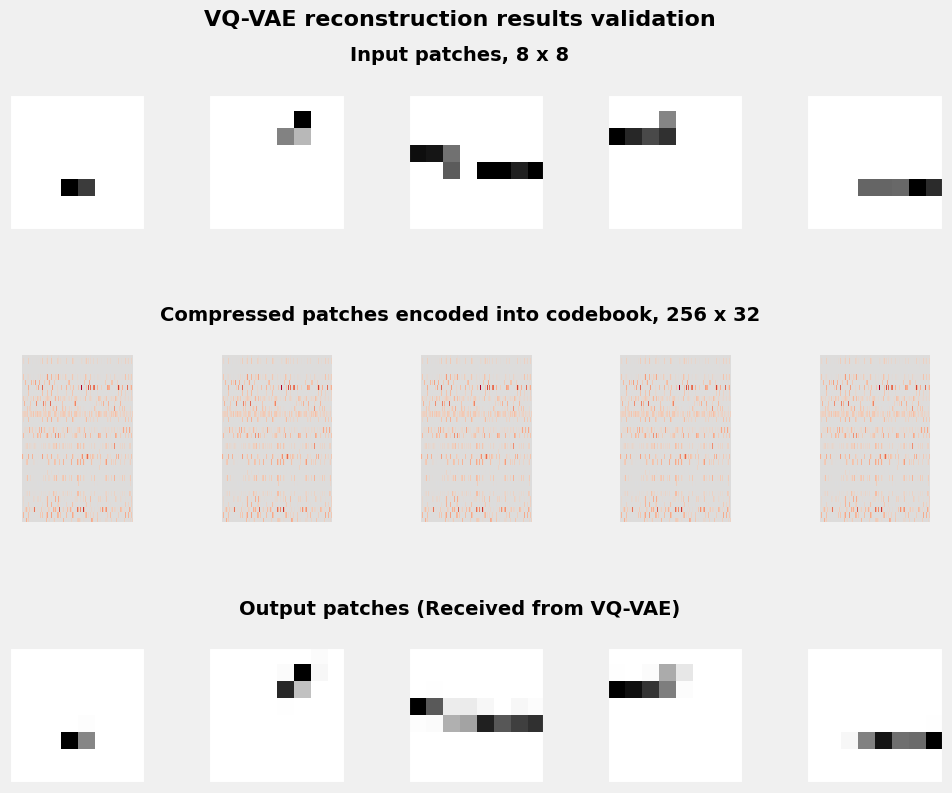

In [240]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_encodings_val, 
     f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
     ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results validation")

In [241]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.014651473611593246
encoder.1.weight 0.001029584906063974
encoder.1.bias 0.0013998312642797828
encoder.3.weight 0.025790879502892494
encoder.4.weight 0.0010678354883566499
encoder.4.bias 0.0009755010833032429
encoder.6.weight 0.03524315729737282
encoder.7.weight 0.0033668815158307552
encoder.7.bias 0.003128559561446309
encoder.8.stack.0.res_block.1.weight 0.010371878743171692
encoder.8.stack.0.res_block.3.weight 0.012695138342678547
encoder.8.stack.1.res_block.1.weight 0.0072573223151266575
encoder.8.stack.1.res_block.3.weight 0.0042796991765499115
vq_layer.embedding.weight 0.00047747589997015893
decoder.0.weight 0.01583627052605152
decoder.1.weight 0.0018190027913078666
decoder.1.bias 0.001463772845454514
decoder.2.stack.0.res_block.1.weight 0.003381469054147601
decoder.2.stack.0.res_block.3.weight 0.0038770893588662148
decoder.2.stack.1.res_block.1.weight 0.002581930486485362
decoder.2.stack.1.res_block.3.weight 0.0021694661118090153
decoder.

VQ VAE, BCE encoder average loss values over epochs


/tmp/ipykernel_466343/831797292.py:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


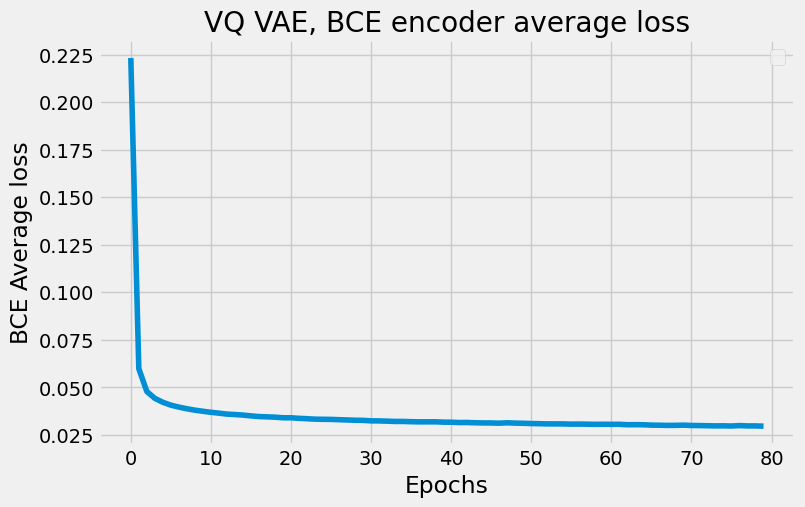

Saved VQ-VAE loss train data to csv
Saved VQ-VAE loss validation data to csv


In [242]:
# display loss values
plot_metric_results(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

# Saving train loss data
data_csv = pd.DataFrame(
    {
        "vq_average_loss" : average_loss_train,
        "bce_average_train_loss" : average_loss_train_bce,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_train.csv",index=False)
print("Saved VQ-VAE loss train data to csv")

# Saving validation loss data
data_csv = pd.DataFrame(
    {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse_val,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_val.csv",index=False)
print("Saved VQ-VAE loss validation data to csv")


In [243]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 6
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _
    ) = model(patch_test)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(_tensor_to_numpy(codebook_test))
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

# saving
test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
        "average_perplexity_test" : [perplexity_average]
    }
)
test_df_frame.to_csv("vqvae_test_loss.csv")
print("Saved VQ-VAE test results")

Based on test set (size = 45), average BCE loss = 0.21081
Based on test set (size = 45), average codebook perplexity = 112.43329/256
Saved VQ-VAE test results


In [244]:
len(patches_before_test)

6

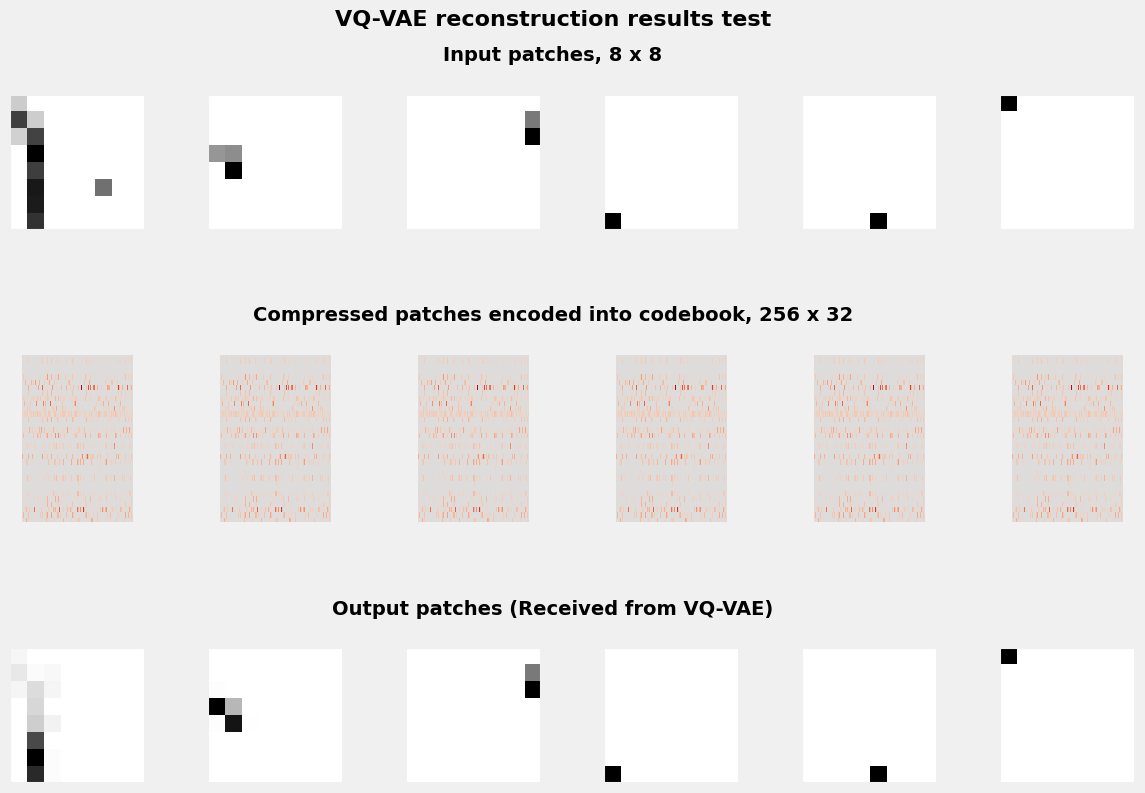

In [245]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results test")

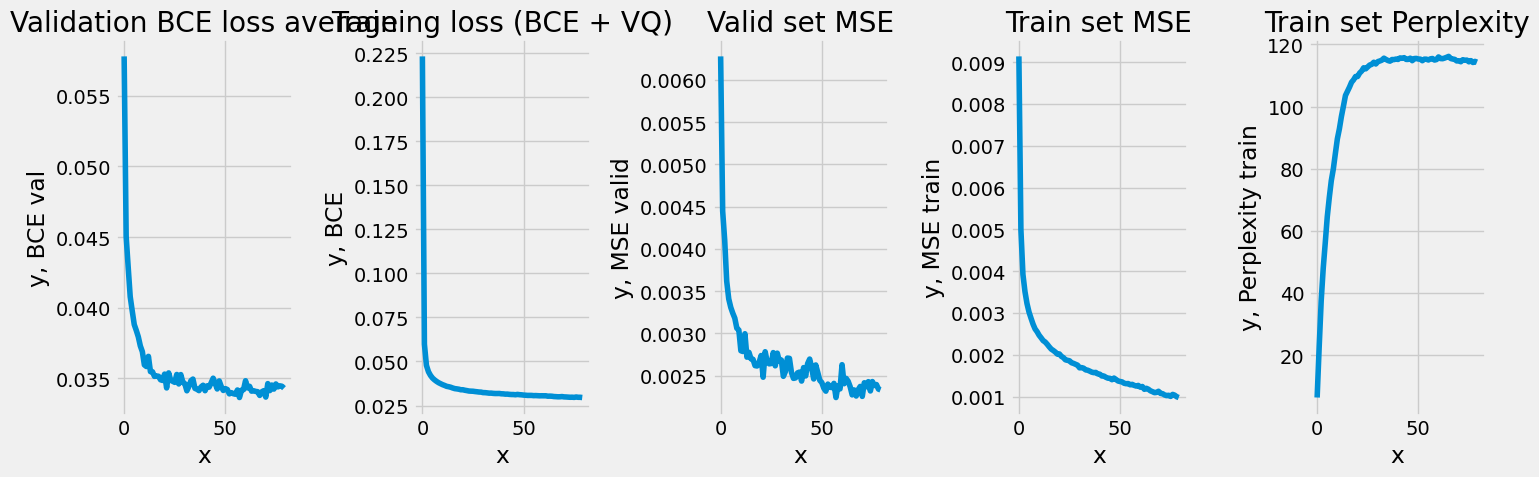

In [246]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

fig, axes = plt.subplots(1, len(values_to_plot), figsize=(15, 5))

for i, (x, y, title, y_label) in enumerate(values_to_plot):
    axes[i].plot(
        x,
        y,
    )
    axes[i].grid(True)
    axes[i].set_title(title)
    axes[i].set_xlabel("x")
    axes[i].set_ylabel(f"y, {y_label}")
    
    for spine in axes[i].spines.values():
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

# print(title + " values over epochs")
# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(x_values, y_values, marker=marker)
# plt.xlabel(x_label)
# plt.ylabel(y_title)
# plt.legend()
# plt.title(title)
# plt.show()

Results:
<!-- * Perplexity shows that per patch about 10 from 16 codebook entries are used
* Reconstruction quality is about average. Representations with validation and test tests
look marginally similar to the input images
* Compression ratio shows that input image successfully was scaled about 3 times (~2.8).
* 1 encoded patch has 27 bits, while 1 encoded patch in VAE has 128 bits. 
* beta = 4e-3 (commitment cost) given better results. Beta needs to be very small and once smaller, gives better results. Based on official VQ-VAE research paper, image compression, requires beta to in the inverval [0.1, 2.0] -->
* Codebook entries from 16 vectors (rows), only approximately 8 codebook entries are used based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction
* Validation set properly works with higher beta coeficient
* Codebook plots describe codebook variation, whether certain weights are mostly zero and are codebook usage is not sparse